
# Jamshidian's Trick in Financial Engineering

Jamshidian's Trick is a powerful technique in quantitative finance used to simplify the computation of expectations that involve the maximum function over a sum. Instead of directly computing an expectation of the form

$$
E\left[\max\left(\sum_{i=0}^{N-1} X_i - K, \, 0\right)\right],
$$

Jamshidian's Trick decomposes it into a sum of easier-to-compute expectations. This approach is particularly useful in pricing complex derivatives like interest rate swaptions and basket options.

---

## Detailed Code Explanation

The following is a step-by-step explanation of the code that implements Jamshidian's Trick.

### 1. Imports

```python
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize
```

- **`numpy`** is used for numerical operations and random number generation.
- **`matplotlib.pyplot`** is used for plotting the results.
- **`scipy.optimize`** is used to solve nonlinear equations numerically (here, Newton's method).

---

### 2. Function: `PsiSum`

```python
def PsiSum(psi, N, x):
    temp = 0
    for i in range(0, N):
        temp = temp + psi(i, x)
    return temp
```

This function computes the sum of basis functions:

$$
\Psi(x) = \sum_{i=0}^{N-1} \psi_i(x),
$$

where each basis function $\psi_i(x)$ will be defined later. The function loops over $i$ from 0 to $N-1$ and sums $\psi_i(x)$.

---

### 3. Function: `JamshidianTrick`

```python
def JamshidianTrick(psi, N, K):
    A = lambda x: PsiSum(psi, N, x) - K
    result = optimize.newton(A, 0.1)
    return result
```

This function finds the value $x^*$ such that

$$
\Psi(x^*) = \sum_{i=0}^{N-1} \psi_i(x^*) = K.
$$

- The lambda function, 
  $$
  A(x) = \Psi(x) - K,
  $$
  is constructed so that finding its root $A(x^*) = 0$ gives the required $x^*$.
- `optimize.newton(A, 0.1)` is used to solve for $x^*$ numerically using Newton's method.

---

### 4. Function: `Main`

```python
def Main():
    NoOfSamples = 1000
    X = np.random.normal(0.0, 1.0, [NoOfSamples, 1])
    
    psi_i = lambda i, X: np.exp(-i * np.abs(X))
    
    N = 15
    A = 0
    for i in range(0, N):
        A = A + psi_i(i, X)
    
    K = np.linspace(2, 10, 10)
    resultMC = np.zeros(len(K))
    for (i, Ki) in enumerate(K):
        resultMC[i] = np.mean(np.maximum(A - Ki, 0))
    
    resultJams = np.zeros(len(K))
    for i, Ki in enumerate(K):
        optX = JamshidianTrick(psi_i, N, Ki)
        A = 0
        for j in range(0, N):
            A = A + np.mean(np.maximum(psi_i(j, X) - psi_i(j, optX), 0))
        resultJams[i] = A
        
    plt.figure()
    plt.plot(K, resultMC)
    plt.plot(K, resultJams, '--r')
    plt.grid()
    plt.xlabel('K')
    plt.ylabel('Expectation')
    plt.legend(['Monte Carlo', 'Jamshidian\'s Trick'])
```

**Explanation of the Steps:**

1. **Sample Generation:**

   - Generates 1000 samples from a standard normal distribution:
     
     $$
     X \sim \mathcal{N}(0, 1)
     $$

2. **Defining Basis Functions:**

   - The basis function is defined as:
     
     $$
     \psi_i(X) = e^{-i \, |X|}.
     $$

3. **Computing the Sum of Basis Functions:**

   - The variable $A$ is computed as:
     
     $$
     A = \sum_{i=0}^{N-1} \psi_i(X),
     $$
     
     where $N = 15$.

4. **Monte Carlo Expectation:**

   - For a range of strike values $K$, the expectation is computed using Monte Carlo:
     
     $$
     E\left[\max\left(A - K, \, 0\right)\right],
     $$
     
     which is approximated by the sample mean.

5. **Jamshidian's Trick Expectation:**

   - For each $K$, the function `JamshidianTrick` finds $x^*$ such that:
     
     $$
     \sum_{i=0}^{N-1} \psi_i(x^*) = K.
     $$
     
   - Then, the expectation is computed as:
     
     $$
     \sum_{i=0}^{N-1} E\left[\max\left(\psi_i(X) - \psi_i(x^*), \, 0\right)\right].
     $$

6. **Plotting the Results:**

   - The Monte Carlo estimates and the estimates from Jamshidian's Trick are plotted against $K$ for comparison.

---

## Theoretical Background of Jamshidian's Trick

The trick is employed to simplify the pricing of options where the payoff involves a maximum over a sum, for example:

$$
E\left[\max\left(\sum_{i=0}^{N-1} \psi_i(X) - K, \, 0\right)\right].
$$

**Key Idea:**

Instead of tackling the above multi-dimensional problem directly, Jamshidian's Trick splits the problem into the following two steps:

1. **Find the Critical Point:**
   
   Determine $x^*$ such that:

   $$
   \sum_{i=0}^{N-1} \psi_i(x^*) = K.
   $$

2. **Decompose the Expectation:**
   
   Rewrite the expectation as:

   $$
   \sum_{i=0}^{N-1} E\left[\max\left(\psi_i(X) - \psi_i(x^*), \, 0\right)\right].
   $$

This decomposition reduces a complex, multidimensional integration problem into several one-dimensional problems, each easier to compute.

**Applications in Finance:**

- **Interest Rate Derivatives:**  
  When pricing swaptions, cash flows depend on a sum of future interest rates. Jamshidian's Trick helps convert the problem into individual components that are easier to handle.

- **Equity Derivatives:**  
  In basket options, where the payoff depends on the weighted sum of several asset prices, this trick simplifies the expectation calculation.

**Benefits:**

- **Reduction in Complexity:**  
  By breaking down a multi-dimensional expectation into a sum of one-dimensional expectations, the computational burden is greatly reduced.

- **Improved Efficiency:**  
  Evaluating several one-dimensional expectations is usually more efficient and numerically stable than handling a multi-dimensional integral.

- **Model Calibration:**  
  The decomposition facilitates calibration of complex models, allowing each component to be handled separately.

---

## Conclusion

Jamshidian's Trick is an elegant and efficient method in quantitative finance for handling complex payoff structures. Its ability to reduce computational complexity makes it an essential tool for pricing derivatives and managing risk in financial models. Understanding and applying this trick will be valuable in both academic studies and practical applications, such as building models for quantitative interviews.

---

*You can execute the above code in a Jupyter Notebook cell to see how Jamshidian's Trick compares with the standard Monte Carlo method.*


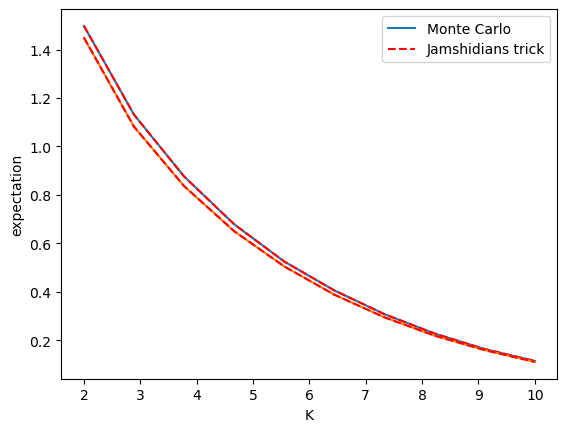

In [5]:

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize

def PsiSum(psi,N,x):
    temp = 0
    for i in range(0,N):
        temp = temp + psi(i,x)
    return temp

def JamshidianTrick(psi,N,K):
    A = lambda x: PsiSum(psi,N,x) - K
    result = optimize.newton(A,0.1)
    return result

def Main():
    NoOfSamples = 1000
    X =  np.random.normal(0.0,1.0,[NoOfSamples,1])
    psi_i = lambda i,X: np.exp(-i*np.abs(X))
    
    # Number of terms
    N = 15
    
    A = 0
    for i in range(0,N):
        A = A + psi_i(i,X)
    
    K = np.linspace(2,10,10)
    resultMC = np.zeros(len(K))
    for (i,Ki) in enumerate(K):
        resultMC[i] = np.mean(np.maximum(A-Ki,0))
    
    # Jamshidians trick
    resultJams = np.zeros(len(K))
    for i,Ki in enumerate(K):
        # Compute optimal K*
        optX = JamshidianTrick(psi_i,N,Ki)
        A = 0
        for j in range(0,N):
            A = A + np.mean(np.maximum(psi_i(j,X)-psi_i(j,optX),0))
        resultJams[i] = A
        
    plt.figure()
    plt.plot(K,resultMC)
    plt.plot(K,resultJams,'--r')
    plt.grid()
    plt.xlabel('K')
    plt.ylabel('expectation')
    plt.legend(['Monte Carlo','Jamshidians trick'])
    
Main()
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize

def PsiSum(psi,N,x):
    temp = 0
    for i in range(0,N):
        temp = temp + psi(i,x)
    return temp

def JamshidianTrick(psi,N,K):
    A = lambda x: PsiSum(psi,N,x) - K
    result = optimize.newton(A,0.1)
    return result

def Main():
    NoOfSamples = 1000
    X =  np.random.normal(0.0,1.0,[NoOfSamples,1])
    psi_i = lambda i,X: np.exp(-i*np.abs(X))
    
    # Number of terms
    N = 15
    
    A = 0
    for i in range(0,N):
        A = A + psi_i(i,X)
    
    K = np.linspace(2,10,10)
    resultMC = np.zeros(len(K))
    for (i,Ki) in enumerate(K):
        resultMC[i] = np.mean(np.maximum(A-Ki,0))
    
    # Jamshidians trick
    resultJams = np.zeros(len(K))
    for i,Ki in enumerate(K):
        # Compute optimal K*
        optX = JamshidianTrick(psi_i,N,Ki)
        A = 0
        for j in range(0,N):
            A = A + np.mean(np.maximum(psi_i(j,X)-psi_i(j,optX),0))
        resultJams[i] = A
        
    plt.figure(1)
    plt.plot(K,resultMC)
    plt.plot(K,resultJams,'--r')
    plt.grid()
    plt.xlabel('K')
    
    plt.ylabel('expectation')
    plt.legend(['Monte Carlo','Jamshidians trick'])
    
Main()